In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

In [55]:
import os
os.makedirs("outputs", exist_ok=True)

In [56]:
df = pd.read_csv("C:/Users/satya/OneDrive/Documents/projects/NetflixOriginals.csv")
df.head()

,Title,Genre,Premiere,Runtime,IMDB Score,Language
0,Enter the Anime,Documentary,"August 5, 2019",58,2.5,English/Japanese
1,Dark Forces,Thriller,"August 21, 2020",81,2.6,Spanish
2,The App,Science fiction/Drama,"December 26, 2019",79,2.6,Italian
3,The Open House,Horror thriller,"January 19, 2018",94,3.2,English
4,Kaali Khuhi,Mystery,"October 30, 2020",90,3.4,Hindi


In [57]:
df.shape

(584, 6)

In [58]:
df.columns

Index(['Title', 'Genre', 'Premiere', 'Runtime', 'IMDB Score', 'Language'], dtype='str')

In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 584 entries, 0 to 583
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Title       584 non-null    str    
 1   Genre       584 non-null    str    
 2   Premiere    584 non-null    str    
 3   Runtime     584 non-null    int64  
 4   IMDB Score  584 non-null    float64
 5   Language    584 non-null    str    
dtypes: float64(1), int64(1), str(4)
memory usage: 27.5 KB


In [60]:
df.isnull().sum()

Title         0
Genre         0
Premiere      0
Runtime       0
IMDB Score    0
Language      0
dtype: int64

In [61]:
df.duplicated().sum()

np.int64(0)

In [62]:
df.describe()

,Runtime,IMDB Score
count,584.000000,584.000000
mean,93.577055,6.271747
std,27.761683,0.979256
min,4.000000,2.500000
25%,86.000000,5.700000
50%,97.000000,6.350000
75%,108.000000,7.000000
max,209.000000,9.000000


In [63]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns

Index(['title', 'genre', 'premiere', 'runtime', 'imdb_score', 'language'], dtype='str')

In [64]:
df["premiere"] = pd.to_datetime(df["premiere"], errors="coerce")
df["runtime"] = pd.to_numeric(df["runtime"], errors="coerce")
df["imdb_score"] = pd.to_numeric(df["imdb_score"], errors="coerce")

In [65]:
df["premiere_year"] = df["premiere"].dt.year

In [66]:
df = df.drop_duplicates()

In [67]:
df.isnull().sum()

title            0
genre            0
premiere         5
runtime          0
imdb_score       0
language         0
premiere_year    5
dtype: int64

In [68]:
df = df.dropna()

In [69]:
df["title"] = df["title"].astype(str).str.strip()
df["genre"] = df["genre"].astype(str).str.strip()
df["language"] = df["language"].astype(str).str.strip()

In [70]:
df[["runtime", "imdb_score", "premiere_year"]].describe()

,runtime,imdb_score,premiere_year
count,579.000000,579.000000,579.000000
mean,93.725389,6.267876,2018.953368
std,27.605455,0.980116,1.465722
min,4.000000,2.500000,2014.000000
25%,86.000000,5.700000,2018.000000
50%,97.000000,6.300000,2019.000000
75%,108.000000,7.000000,2020.000000
max,209.000000,9.000000,2021.000000


In [71]:
print("Unique titles:", df["title"].nunique())
print("Unique genres:", df["genre"].nunique())
print("Unique languages:", df["language"].nunique())

Unique titles: 579
Unique genres: 115
Unique languages: 38


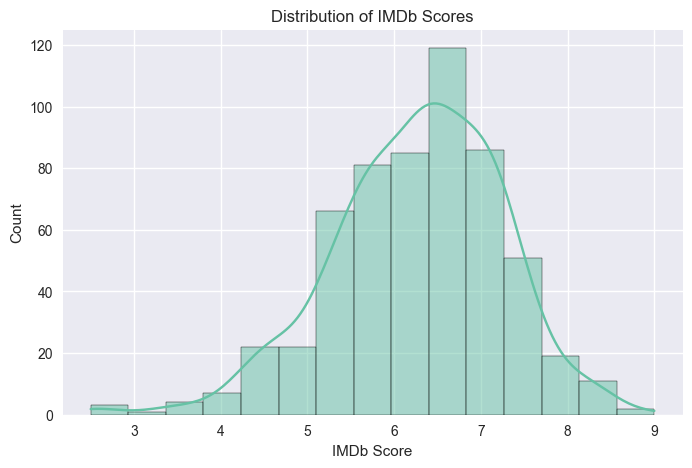

In [72]:
plt.figure(figsize=(8,5))
sns.histplot(df["imdb_score"], bins=15, kde=True)
plt.title("Distribution of IMDb Scores")
plt.xlabel("IMDb Score")
plt.ylabel("Count")

plt.savefig("outputs/distribution of imdb scores", dpi=300, bbox_inches="tight")
plt.show()

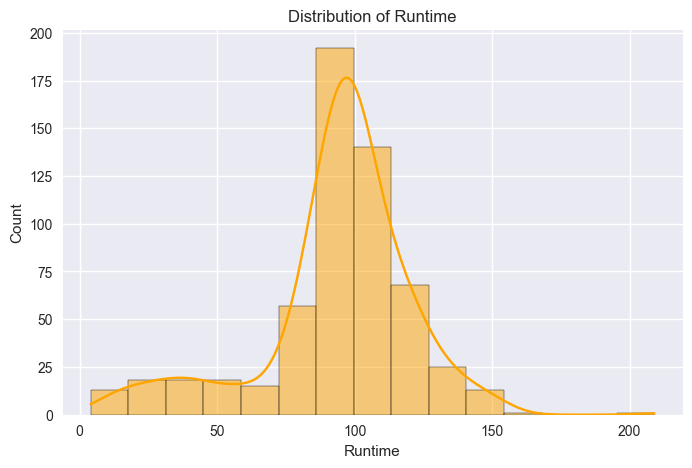

In [73]:
plt.figure(figsize=(8,5))
sns.histplot(df["runtime"], bins=15, kde=True, color="orange")
plt.title("Distribution of Runtime")
plt.xlabel("Runtime")
plt.ylabel("Count")
plt.savefig("outputs/distribution of runtime", dpi=300, bbox_inches="tight")
plt.show()

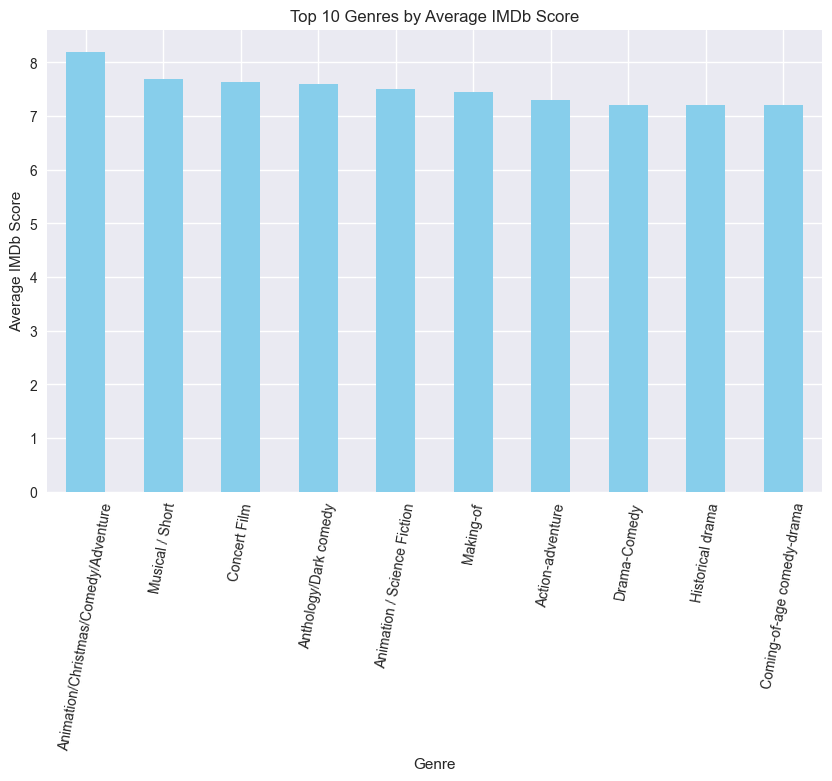

In [74]:
genre_score = df.groupby("genre")["imdb_score"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
genre_score.head(10).plot(kind="bar", color="skyblue")
plt.title("Top 10 Genres by Average IMDb Score")
plt.xlabel("Genre")
plt.ylabel("Average IMDb Score")
plt.xticks(rotation=80)
plt.savefig("outputs/top 10 genres by avg imdb score", dpi=300, bbox_inches="tight")
plt.show()

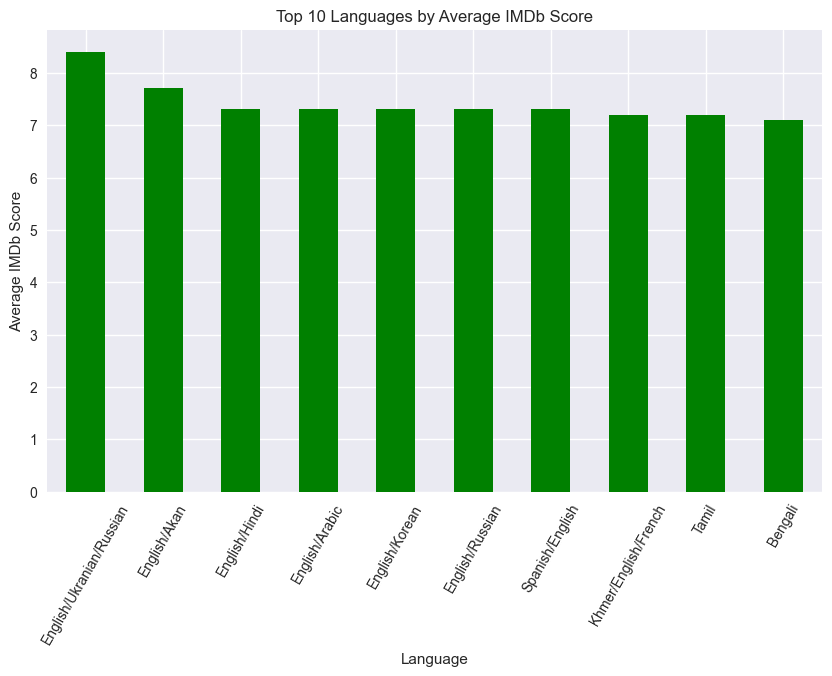

In [75]:
language_score = df.groupby("language")["imdb_score"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
language_score.head(10).plot(kind="bar", color="green")
plt.title("Top 10 Languages by Average IMDb Score")
plt.xlabel("Language")
plt.ylabel("Average IMDb Score")
plt.xticks(rotation=60)
plt.savefig("outputs/top 10 languags by avg imdb score", dpi=300, bbox_inches="tight")
plt.show()

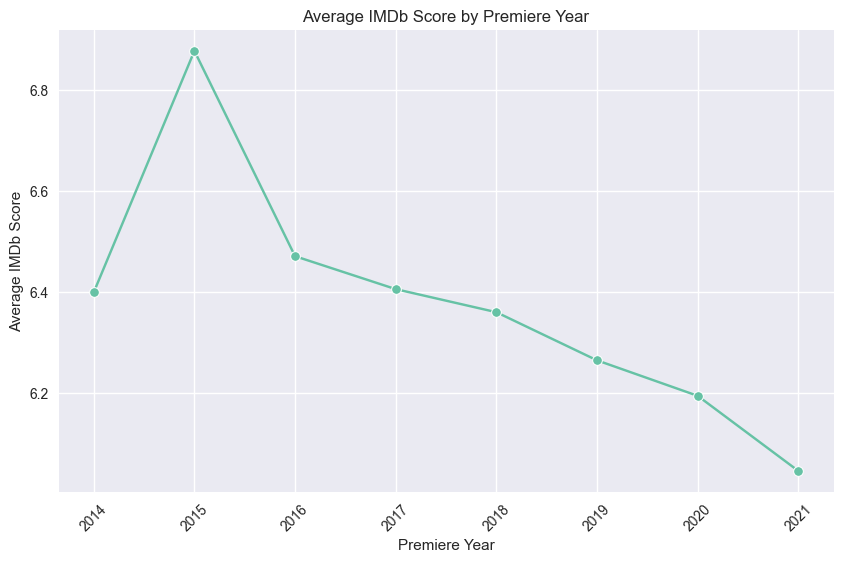

In [76]:
year_score = df.groupby("premiere_year")["imdb_score"].mean().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=year_score, x="premiere_year", y="imdb_score", marker="o")
plt.title("Average IMDb Score by Premiere Year")
plt.xlabel("Premiere Year")
plt.ylabel("Average IMDb Score")
plt.xticks(rotation=45)
plt.savefig("outputs/avg imdb score by premiere year", dpi=300, bbox_inches="tight")
plt.show()

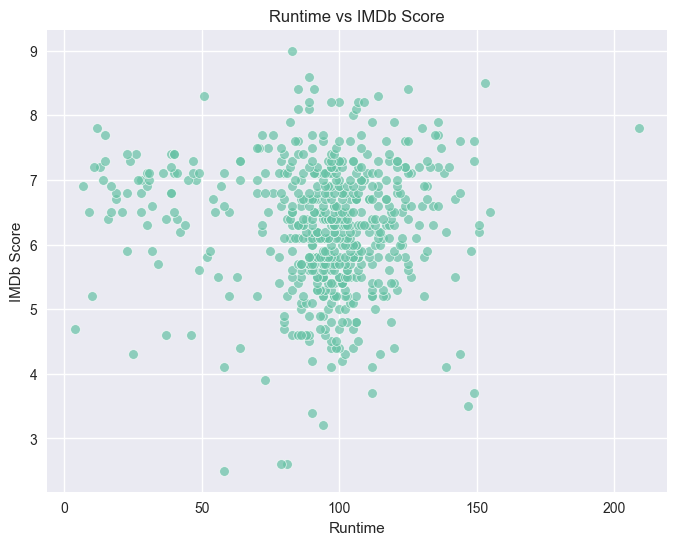

In [77]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="runtime", y="imdb_score", alpha=0.7)
plt.title("Runtime vs IMDb Score")
plt.xlabel("Runtime")
plt.ylabel("IMDb Score")
plt.savefig("outputs/runtime vs imdb score", dpi=300, bbox_inches="tight")
plt.show()

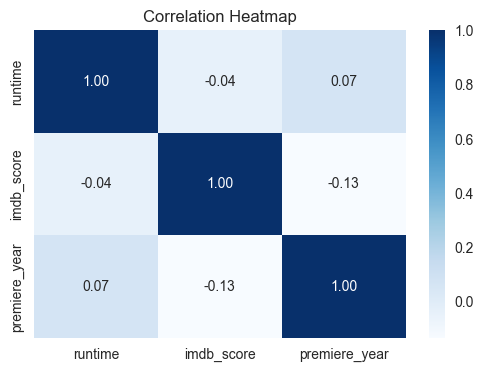

In [78]:
corr = df[["runtime", "imdb_score", "premiere_year"]].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap")
plt.savefig("outputs/correlation heatmap", dpi=300, bbox_inches="tight")
plt.show()

In [79]:
df.sort_values("imdb_score", ascending=False)[["title", "genre", "premiere", "runtime", "imdb_score", "language"]].head(10)

,title,genre,premiere,runtime,imdb_score,language
583,David Attenborough: A Life on Our Planet,Documentary,2020-10-04,83,9.0,English
582,Emicida: AmarElo - It's All For Yesterday,Documentary,2020-12-08,89,8.6,Portuguese
581,Springsteen on Broadway,One-man show,2018-12-16,153,8.5,English
580,Winter on Fire: Ukraine's Fight for Freedom,Documentary,2015-10-09,91,8.4,English/Ukranian/Russian
579,Taylor Swift: Reputation Stadium Tour,Concert Film,2018-12-31,125,8.4,English
578,Ben Platt: Live from Radio City Music Hall,Concert Film,2020-05-20,85,8.4,English
576,Cuba and the Cameraman,Documentary,2017-11-24,114,8.3,English
577,Dancing with the Birds,Documentary,2019-10-23,51,8.3,English
573,Klaus,Animation/Christmas/Comedy/Adventure,2019-11-15,97,8.2,English
572,Disclosure: Trans Lives on Screen,Documentary,2020-06-19,107,8.2,English


In [80]:
df.sort_values("imdb_score", ascending=True)[["title", "genre", "premiere", "runtime", "imdb_score", "language"]].head(10)

,title,genre,premiere,runtime,imdb_score,language
0,Enter the Anime,Documentary,2019-08-05,58,2.5,English/Japanese
1,Dark Forces,Thriller,2020-08-21,81,2.6,Spanish
2,The App,Science fiction/Drama,2019-12-26,79,2.6,Italian
3,The Open House,Horror thriller,2018-01-19,94,3.2,English
4,Kaali Khuhi,Mystery,2020-10-30,90,3.4,Hindi
5,Drive,Action,2019-11-01,147,3.5,Hindi
6,Leyla Everlasting,Comedy,2020-12-04,112,3.7,Turkish
7,The Last Days of American Crime,Heist film/Thriller,2020-06-05,149,3.7,English
8,Paradox,Musical/Western/Fantasy,2018-03-23,73,3.9,English
9,Sardar Ka Grandson,Comedy,2021-05-18,139,4.1,Hindi


In [81]:
df.to_csv("netflix_imdb_cleaned.csv", index=False)